# London House Price Prediction Model Training

This notebook trains machine learning models to predict London house prices and exports the best performing model.

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Model persistence
import joblib
import pickle

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the dataset
df = pd.read_csv('London.csv', index_col=0)

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset Shape: (3480, 10)

Columns: ['Property Name', 'Price', 'House Type', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions', 'Location', 'City/County', 'Postal Code']

First few rows:


,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code
0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY
1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA
2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL
3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP
4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL


In [3]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3480 entries, 0 to 3479
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Property Name      3480 non-null   object
 1   Price              3480 non-null   int64 
 2   House Type         3480 non-null   object
 3   Area in sq ft      3480 non-null   int64 
 4   No. of Bedrooms    3480 non-null   int64 
 5   No. of Bathrooms   3480 non-null   int64 
 6   No. of Receptions  3480 non-null   int64 
 7   Location           2518 non-null   object
 8   City/County        3480 non-null   object
 9   Postal Code        3480 non-null   object
dtypes: int64(5), object(5)
memory usage: 299.1+ KB
None


Basic Statistics:


,Price,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions
count,3.480000e+03,3480.000000,3480.000000,3480.000000,3480.000000
mean,1.864173e+06,1712.973563,3.103736,3.103736,3.103736
std,2.267283e+06,1364.259351,1.517698,1.517698,1.517698
min,1.800000e+05,274.000000,0.000000,0.000000,0.000000
25%,7.500000e+05,834.000000,2.000000,2.000000,2.000000
50%,1.220000e+06,1310.000000,3.000000,3.000000,3.000000
75%,2.150000e+06,2157.250000,4.000000,4.000000,4.000000
max,3.975000e+07,15405.000000,10.000000,10.000000,10.000000


In [4]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing Values:
          Missing Count  Percentage
Location            962   27.643678


## 3. Data Visualization

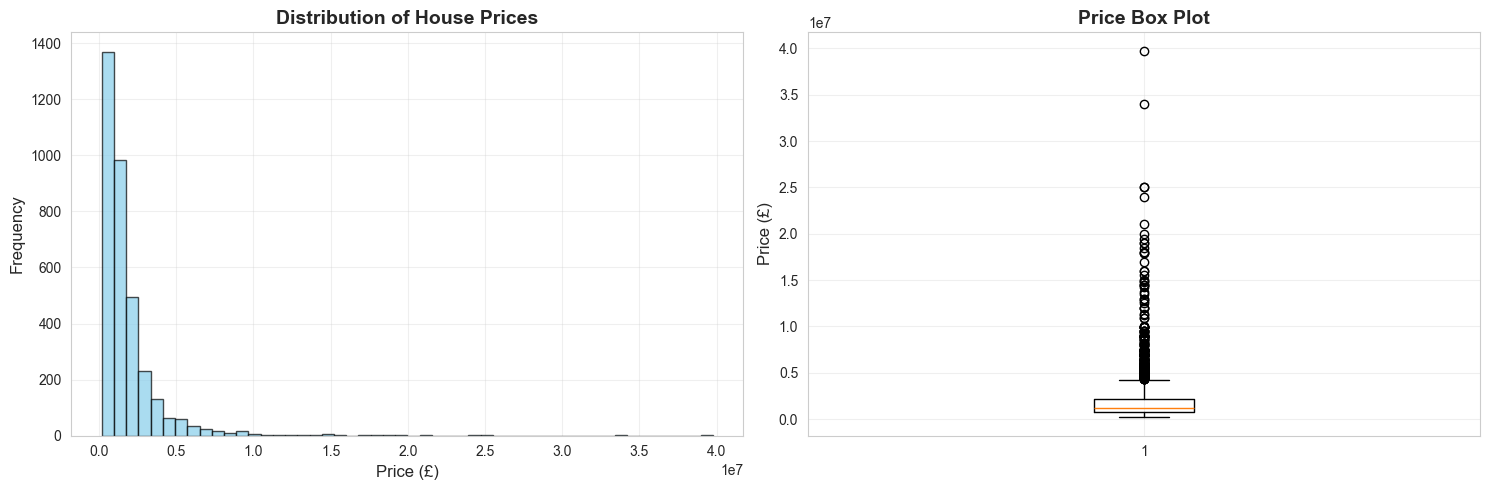


Price Statistics:
Mean Price: £1,864,172.54
Median Price: £1,220,000.00
Min Price: £180,000.00
Max Price: £39,750,000.00


In [5]:
# Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['Price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (£)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['Price'], vert=True)
axes[1].set_ylabel('Price (£)', fontsize=12)
axes[1].set_title('Price Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrice Statistics:")
print(f"Mean Price: £{df['Price'].mean():,.2f}")
print(f"Median Price: £{df['Price'].median():,.2f}")
print(f"Min Price: £{df['Price'].min():,.2f}")
print(f"Max Price: £{df['Price'].max():,.2f}")

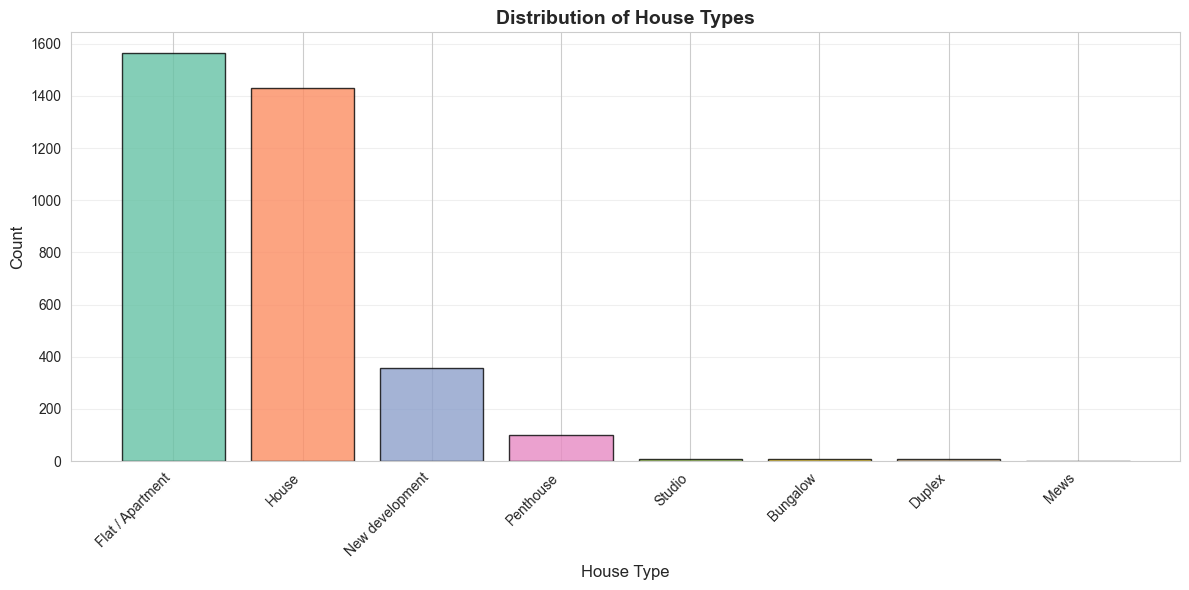


House Type Counts:
House Type
Flat / Apartment    1565
House               1430
New development      357
Penthouse            100
Studio                10
Bungalow               9
Duplex                 7
Mews                   2
Name: count, dtype: int64


In [6]:
# House Type Distribution
plt.figure(figsize=(12, 6))
house_type_counts = df['House Type'].value_counts()
colors = sns.color_palette('Set2', len(house_type_counts))
plt.bar(range(len(house_type_counts)), house_type_counts.values, color=colors, edgecolor='black', alpha=0.8)
plt.xticks(range(len(house_type_counts)), house_type_counts.index, rotation=45, ha='right')
plt.xlabel('House Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of House Types', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nHouse Type Counts:")
print(house_type_counts)

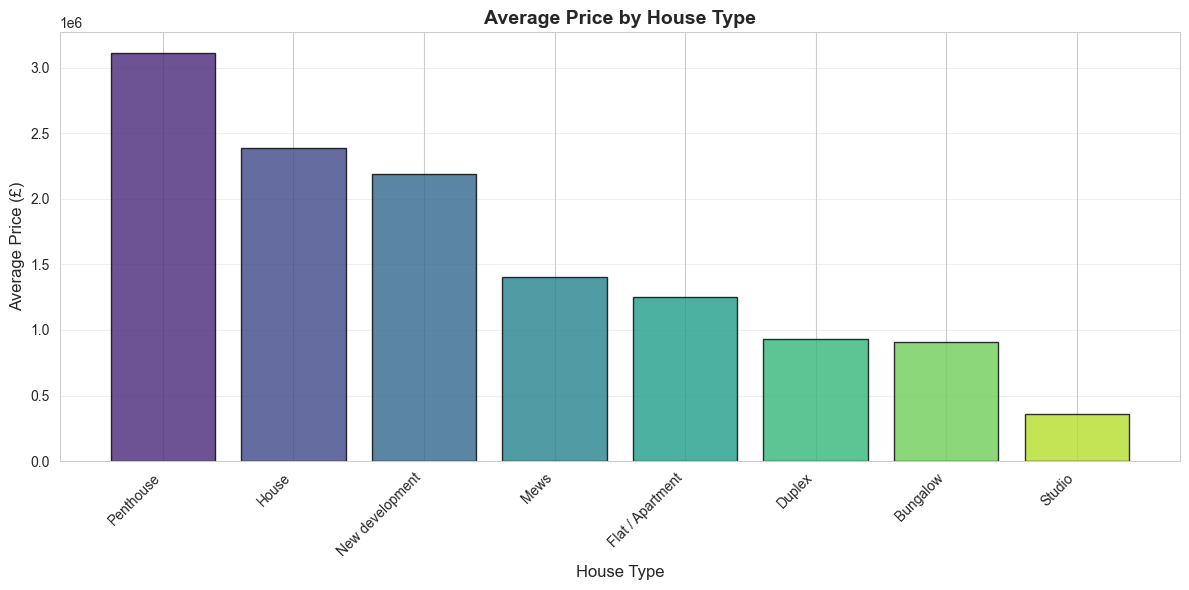


Average Price by House Type:
Penthouse: £3,112,847.45
House: £2,388,377.67
New development: £2,186,311.57
Mews: £1,400,000.00
Flat / Apartment: £1,251,813.03
Duplex: £934,285.71
Bungalow: £904,444.44
Studio: £357,500.00


In [7]:
# Average Price by House Type
plt.figure(figsize=(12, 6))
avg_price_by_type = df.groupby('House Type')['Price'].mean().sort_values(ascending=False)
colors = sns.color_palette('viridis', len(avg_price_by_type))
plt.bar(range(len(avg_price_by_type)), avg_price_by_type.values, color=colors, edgecolor='black', alpha=0.8)
plt.xticks(range(len(avg_price_by_type)), avg_price_by_type.index, rotation=45, ha='right')
plt.xlabel('House Type', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)
plt.title('Average Price by House Type', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nAverage Price by House Type:")
for house_type, price in avg_price_by_type.items():
    print(f"{house_type}: £{price:,.2f}")

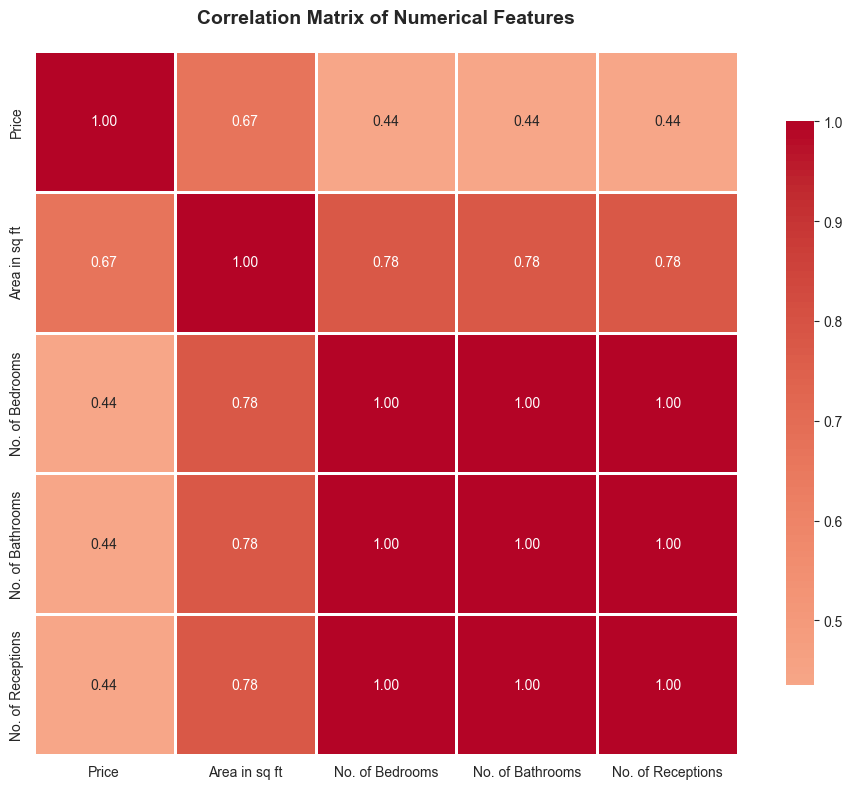

In [8]:
# Correlation heatmap for numerical features
numerical_cols = ['Price', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

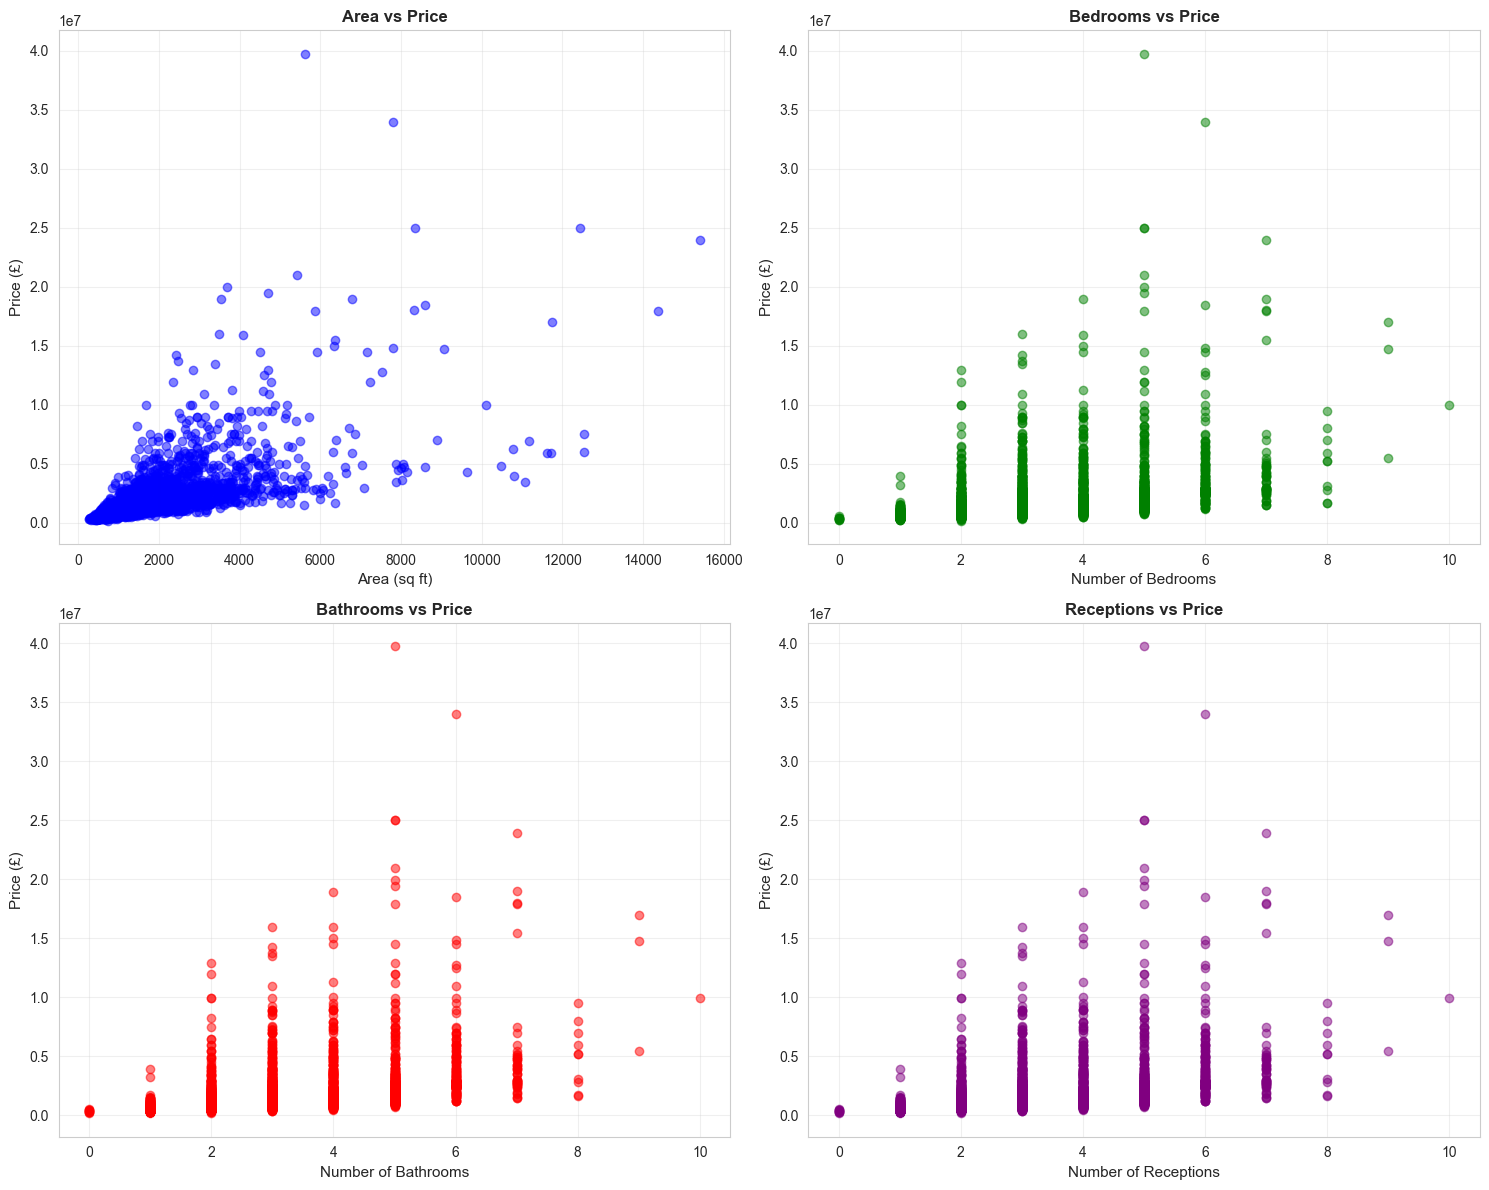

In [9]:
# Scatter plots: Features vs Price
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Area vs Price
axes[0, 0].scatter(df['Area in sq ft'], df['Price'], alpha=0.5, color='blue')
axes[0, 0].set_xlabel('Area (sq ft)', fontsize=11)
axes[0, 0].set_ylabel('Price (£)', fontsize=11)
axes[0, 0].set_title('Area vs Price', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Bedrooms vs Price
axes[0, 1].scatter(df['No. of Bedrooms'], df['Price'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Number of Bedrooms', fontsize=11)
axes[0, 1].set_ylabel('Price (£)', fontsize=11)
axes[0, 1].set_title('Bedrooms vs Price', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Bathrooms vs Price
axes[1, 0].scatter(df['No. of Bathrooms'], df['Price'], alpha=0.5, color='red')
axes[1, 0].set_xlabel('Number of Bathrooms', fontsize=11)
axes[1, 0].set_ylabel('Price (£)', fontsize=11)
axes[1, 0].set_title('Bathrooms vs Price', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Receptions vs Price
axes[1, 1].scatter(df['No. of Receptions'], df['Price'], alpha=0.5, color='purple')
axes[1, 1].set_xlabel('Number of Receptions', fontsize=11)
axes[1, 1].set_ylabel('Price (£)', fontsize=11)
axes[1, 1].set_title('Receptions vs Price', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

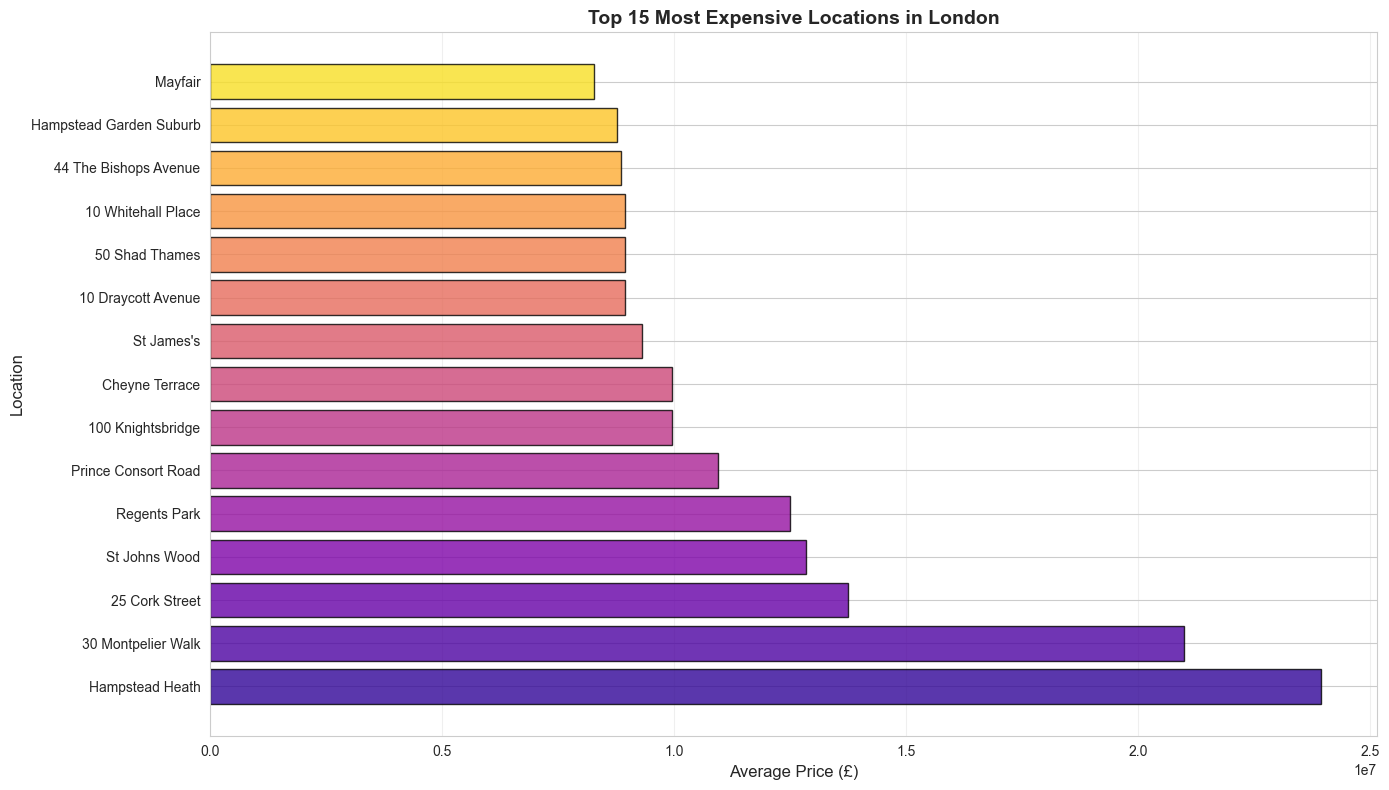


Top 15 Locations by Average Price:
1. Hampstead Heath: £23,950,000.00 (n=1)
2. 30 Montpelier Walk: £21,000,000.00 (n=1)
3. 25 Cork Street: £13,750,000.00 (n=1)
4. St Johns Wood: £12,849,975.00 (n=2)
5. Regents Park: £12,500,000.00 (n=1)
6. Prince Consort Road: £10,950,000.00 (n=1)
7. 100 Knightsbridge: £9,950,000.00 (n=1)
8. Cheyne Terrace: £9,950,000.00 (n=1)
9.  St James's: £9,300,000.00 (n=1)
10. 10 Draycott Avenue: £8,950,000.00 (n=1)
11.  50 Shad Thames: £8,950,000.00 (n=1)
12. 10 Whitehall Place: £8,950,000.00 (n=2)
13. 44 The Bishops Avenue: £8,850,000.00 (n=1)
14. Hampstead Garden Suburb: £8,765,000.00 (n=3)
15. Mayfair: £8,280,208.33 (n=24)


In [10]:
# Top 15 locations by average price
location_data = df[df['Location'].notna()]
top_locations = location_data.groupby('Location')['Price'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(14, 8))
colors = sns.color_palette('plasma', len(top_locations))
plt.barh(range(len(top_locations)), top_locations['mean'].values, color=colors, edgecolor='black', alpha=0.8)
plt.yticks(range(len(top_locations)), top_locations.index)
plt.xlabel('Average Price (£)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.title('Top 15 Most Expensive Locations in London', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 15 Locations by Average Price:")
for idx, (location, row) in enumerate(top_locations.iterrows(), 1):
    print(f"{idx}. {location}: £{row['mean']:,.2f} (n={int(row['count'])})")

## 4. Data Preprocessing

In [11]:
# Create a copy for preprocessing
df_processed = df.copy()

# Select relevant features
features_to_use = ['House Type', 'Area in sq ft', 'No. of Bedrooms', 
                   'No. of Bathrooms', 'No. of Receptions', 'Location']

# Handle missing values
# Fill missing locations with 'Unknown'
df_processed['Location'].fillna('Unknown', inplace=True)

# Drop rows with missing critical features
df_processed = df_processed.dropna(subset=['Price', 'Area in sq ft', 'House Type'])

# Fill missing values for other numerical features with median
for col in ['No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions']:
    df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"Dataset shape after cleaning: {df_processed.shape}")
print(f"\nRemaining missing values:")
print(df_processed[features_to_use + ['Price']].isnull().sum())

Dataset shape after cleaning: (3480, 10)

Remaining missing values:
House Type           0
Area in sq ft        0
No. of Bedrooms      0
No. of Bathrooms     0
No. of Receptions    0
Location             0
Price                0
dtype: int64


In [12]:
# Remove outliers using IQR method for Price
Q1 = df_processed['Price'].quantile(0.25)
Q3 = df_processed['Price'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 3 * IQR  # Using 3*IQR for less aggressive removal
upper_bound = Q3 + 3 * IQR

print(f"Price outlier bounds: £{lower_bound:,.2f} - £{upper_bound:,.2f}")

# Filter outliers
before_outlier_removal = len(df_processed)
df_processed = df_processed[(df_processed['Price'] >= lower_bound) & (df_processed['Price'] <= upper_bound)]
after_outlier_removal = len(df_processed)

print(f"Rows before outlier removal: {before_outlier_removal}")
print(f"Rows after outlier removal: {after_outlier_removal}")
print(f"Outliers removed: {before_outlier_removal - after_outlier_removal} ({((before_outlier_removal - after_outlier_removal) / before_outlier_removal * 100):.2f}%)")

Price outlier bounds: £-3,450,000.00 - £6,350,000.00
Rows before outlier removal: 3480
Rows after outlier removal: 3360
Outliers removed: 120 (3.45%)


In [13]:
# Encode categorical variables
label_encoders = {}

# Encode House Type
le_house_type = LabelEncoder()
df_processed['House Type Encoded'] = le_house_type.fit_transform(df_processed['House Type'])
label_encoders['House Type'] = le_house_type

# Encode Location
le_location = LabelEncoder()
df_processed['Location Encoded'] = le_location.fit_transform(df_processed['Location'])
label_encoders['Location'] = le_location

print("Encoded Categories:")
print(f"\nHouse Types: {len(le_house_type.classes_)} unique types")
for i, house_type in enumerate(le_house_type.classes_):
    print(f"  {i}: {house_type}")

print(f"\nLocations: {len(le_location.classes_)} unique locations")

Encoded Categories:

House Types: 8 unique types
  0: Bungalow
  1: Duplex
  2: Flat / Apartment
  3: House
  4: Mews
  5: New development
  6: Penthouse
  7: Studio

Locations: 640 unique locations


In [14]:
# Prepare features and target
feature_columns = ['House Type Encoded', 'Area in sq ft', 'No. of Bedrooms', 
                  'No. of Bathrooms', 'No. of Receptions', 'Location Encoded']

X = df_processed[feature_columns]
y = df_processed['Price']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used:")
for col in feature_columns:
    print(f"  - {col}")

Feature matrix shape: (3360, 6)
Target vector shape: (3360,)

Features used:
  - House Type Encoded
  - Area in sq ft
  - No. of Bedrooms
  - No. of Bathrooms
  - No. of Receptions
  - Location Encoded


In [15]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set: {(X_train.shape[0] / X.shape[0] * 100):.1f}%")
print(f"Testing set: {(X_test.shape[0] / X.shape[0] * 100):.1f}%")

Training set size: 2688 samples
Testing set size: 672 samples

Training set: 80.0%
Testing set: 20.0%


In [16]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Scaled feature stds (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

✅ Features scaled using StandardScaler

Scaled feature means (should be ~0): [ 0. -0. -0. -0. -0. -0.]
Scaled feature stds (should be ~1): [1. 1. 1. 1. 1. 1.]


## 5. Model Training and Evaluation

In [17]:
# Define models to train
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

print(f"Training {len(models)} different models...\n")
print("="*70)

Training 7 different models...



In [18]:
# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Store results
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse
    }
    
    print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"  Train MAE: £{train_mae:,.2f} | Test MAE: £{test_mae:,.2f}")
    print(f"  Train RMSE: £{train_rmse:,.2f} | Test RMSE: £{test_rmse:,.2f}")

print("\n" + "="*70)
print("✅ All models trained successfully!")


Training Linear Regression...
  Train R²: 0.4973 | Test R²: 0.4820
  Train MAE: £530,776.82 | Test MAE: £563,297.93
  Train RMSE: £799,047.61 | Test RMSE: £857,536.12

Training Ridge Regression...
  Train R²: 0.4975 | Test R²: 0.4794
  Train MAE: £530,554.31 | Test MAE: £563,686.03
  Train RMSE: £798,895.34 | Test RMSE: £859,684.39

Training Lasso Regression...
  Train R²: 0.4975 | Test R²: 0.4793
  Train MAE: £530,516.87 | Test MAE: £563,664.32
  Train RMSE: £798,895.19 | Test RMSE: £859,777.40

Training Decision Tree...
  Train R²: 0.8388 | Test R²: 0.4237
  Train MAE: £269,751.10 | Test MAE: £542,697.11
  Train RMSE: £452,445.44 | Test RMSE: £904,544.61

Training Random Forest...
  Train R²: 0.9440 | Test R²: 0.6305
  Train MAE: £170,232.62 | Test MAE: £460,066.97
  Train RMSE: £266,674.92 | Test RMSE: £724,318.68

Training Gradient Boosting...
  Train R²: 0.7204 | Test R²: 0.6549
  Train MAE: £393,982.64 | Test MAE: £443,919.74
  Train RMSE: £595,921.28 | Test RMSE: £699,976.84

T

In [19]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train R²': [results[m]['train_r2'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()]
}).sort_values('Test R²', ascending=False)

print("\n📊 Model Performance Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


📊 Model Performance Comparison:
            Model  Train R²  Test R²      Test MAE     Test RMSE
          XGBoost  0.929033 0.696065 405754.725121 656889.884266
Gradient Boosting  0.720397 0.654886 443919.738546 699976.841686
    Random Forest  0.944008 0.630466 460066.973204 724318.676896
Linear Regression  0.497300 0.482035 563297.929843 857536.121612
 Ridge Regression  0.497492 0.479437 563686.034034 859684.392740
 Lasso Regression  0.497492 0.479324 563664.315947 859777.399127
    Decision Tree  0.838826 0.423691 542697.109923 904544.609767


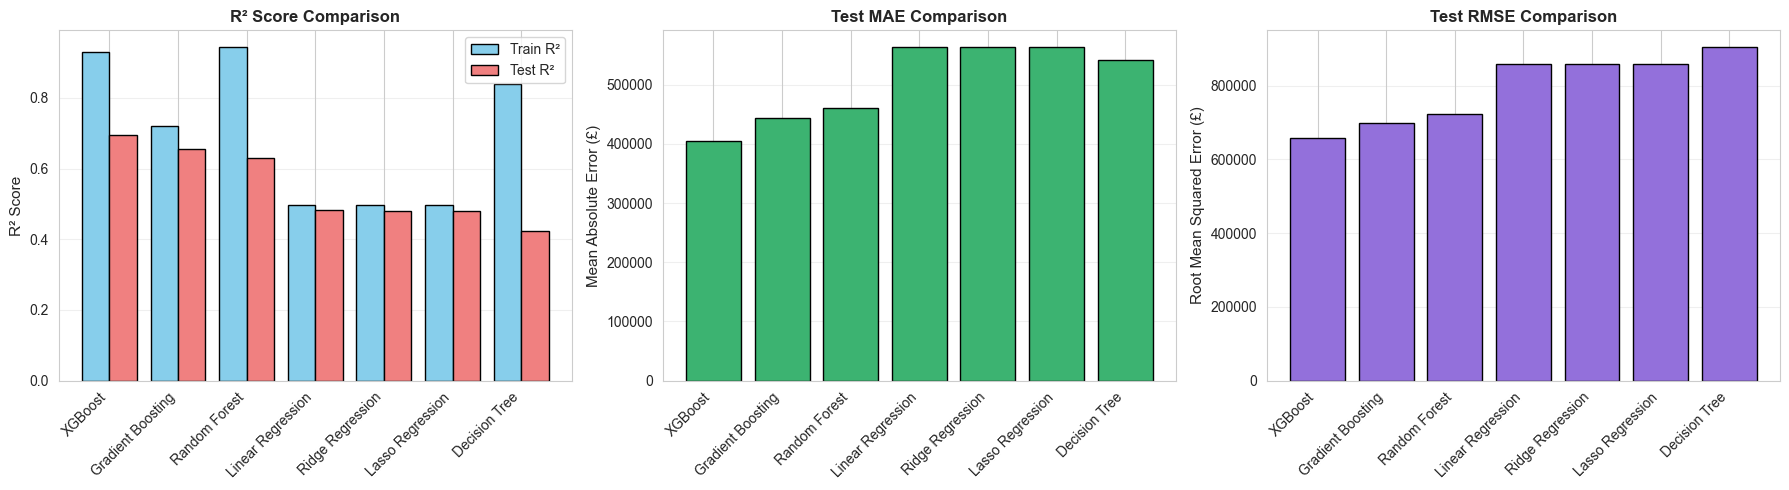

In [20]:
# Visualize model performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = comparison_df['Model'].values
x_pos = np.arange(len(model_names))

# R² Score comparison
axes[0].bar(x_pos - 0.2, comparison_df['Train R²'], 0.4, label='Train R²', color='skyblue', edgecolor='black')
axes[0].bar(x_pos + 0.2, comparison_df['Test R²'], 0.4, label='Test R²', color='lightcoral', edgecolor='black')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[1].bar(x_pos, comparison_df['Test MAE'], color='mediumseagreen', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_ylabel('Mean Absolute Error (£)', fontsize=11)
axes[1].set_title('Test MAE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# RMSE comparison
axes[2].bar(x_pos, comparison_df['Test RMSE'], color='mediumpurple', edgecolor='black')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(model_names, rotation=45, ha='right')
axes[2].set_ylabel('Root Mean Squared Error (£)', fontsize=11)
axes[2].set_title('Test RMSE Comparison', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Select and Optimize Best Model

In [21]:
# Select best model based on Test R²
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"🏆 Best Model: {best_model_name}")
print(f"\nPerformance Metrics:")
print(f"  Test R² Score: {results[best_model_name]['test_r2']:.4f}")
print(f"  Test MAE: £{results[best_model_name]['test_mae']:,.2f}")
print(f"  Test RMSE: £{results[best_model_name]['test_rmse']:,.2f}")

🏆 Best Model: XGBoost

Performance Metrics:
  Test R² Score: 0.6961
  Test MAE: £405,754.73
  Test RMSE: £656,889.88


In [22]:
# Hyperparameter tuning for the best model (if it's Random Forest or XGBoost)
if best_model_name in ['Random Forest', 'XGBoost']:
    print(f"\n🔧 Performing hyperparameter tuning for {best_model_name}...\n")
    
    if best_model_name == 'Random Forest':
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    else:  # XGBoost
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 0.9, 1.0]
        }
        base_model = XGBRegressor(random_state=42, n_jobs=-1)
    
    # Perform grid search
    grid_search = GridSearchCV(
        base_model, 
        param_grid, 
        cv=5, 
        scoring='r2', 
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    # Update best model with tuned parameters
    best_model = grid_search.best_estimator_
    
    # Evaluate tuned model
    y_test_pred_tuned = best_model.predict(X_test_scaled)
    tuned_r2 = r2_score(y_test, y_test_pred_tuned)
    tuned_mae = mean_absolute_error(y_test, y_test_pred_tuned)
    tuned_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
    
    print(f"\n✅ Hyperparameter tuning completed!")
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"\nTuned Model Performance:")
    print(f"  Test R² Score: {tuned_r2:.4f} (improvement: {tuned_r2 - results[best_model_name]['test_r2']:+.4f})")
    print(f"  Test MAE: £{tuned_mae:,.2f}")
    print(f"  Test RMSE: £{tuned_rmse:,.2f}")
    
    # Update results
    results[best_model_name]['test_r2'] = tuned_r2
    results[best_model_name]['test_mae'] = tuned_mae
    results[best_model_name]['test_rmse'] = tuned_rmse
else:
    print(f"\nℹ️ Skipping hyperparameter tuning for {best_model_name}")


🔧 Performing hyperparameter tuning for XGBoost...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Hyperparameter tuning completed!

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}

Tuned Model Performance:
  Test R² Score: 0.7054 (improvement: +0.0093)
  Test MAE: £412,124.87
  Test RMSE: £646,753.65


## 7. Feature Importance Analysis

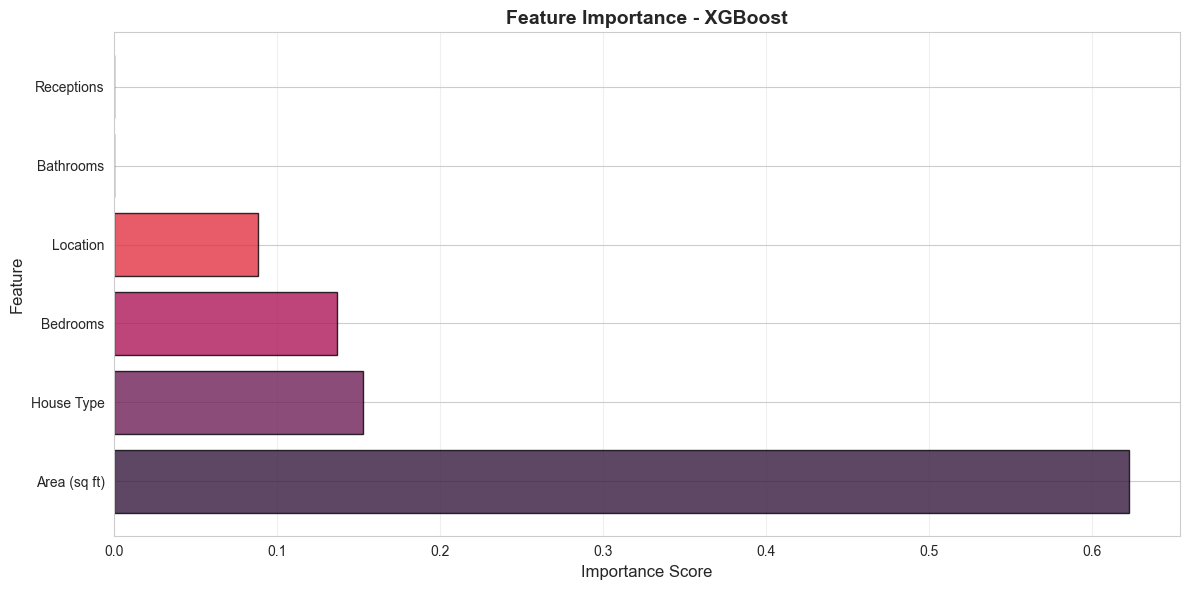


📊 Feature Importance Ranking:
  Area (sq ft): 0.6227
  House Type: 0.1525
  Bedrooms: 0.1365
  Location: 0.0884
  Bathrooms: 0.0000
  Receptions: 0.0000


In [23]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': ['House Type', 'Area (sq ft)', 'Bedrooms', 'Bathrooms', 'Receptions', 'Location'],
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    colors = sns.color_palette('rocket', len(feature_importance))
    plt.barh(range(len(feature_importance)), feature_importance['Importance'].values, 
             color=colors, edgecolor='black', alpha=0.8)
    plt.yticks(range(len(feature_importance)), feature_importance['Feature'].values)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Feature Importance Ranking:")
    for idx, row in feature_importance.iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
else:
    print(f"\nℹ️ Feature importance not available for {best_model_name}")

## 8. Prediction Visualization

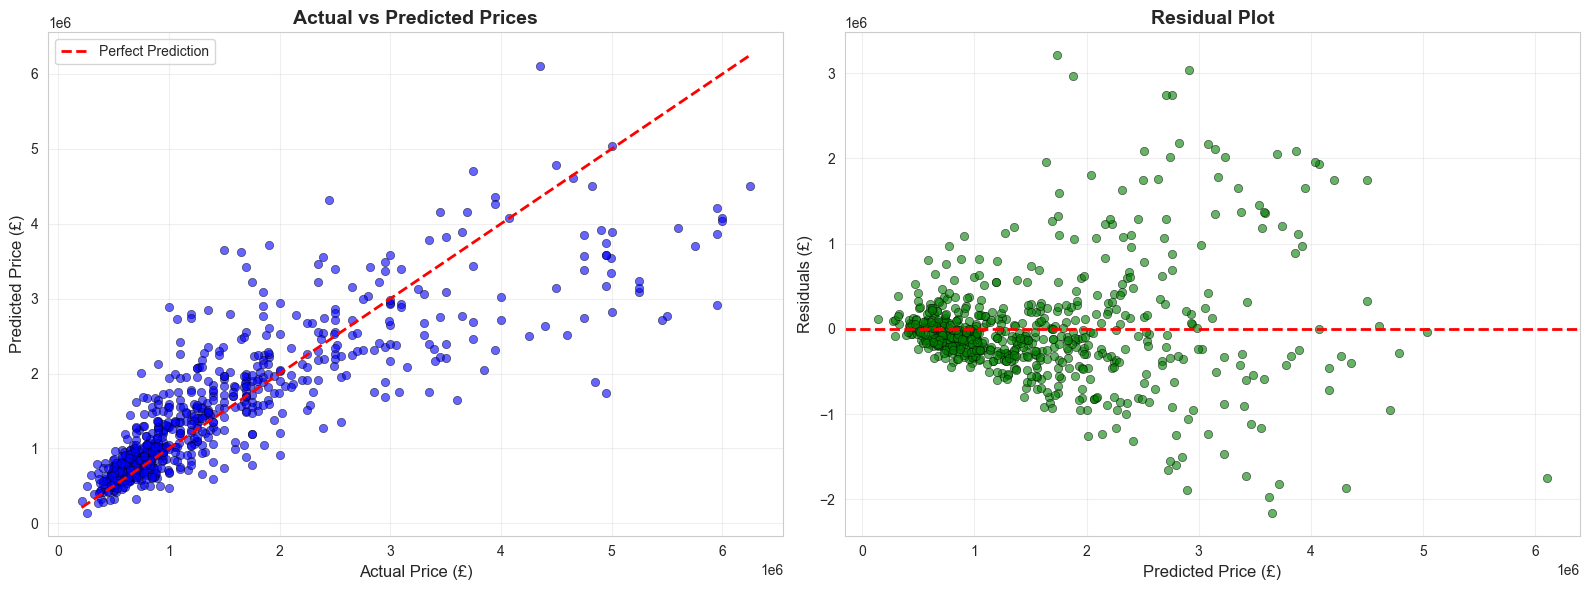

In [24]:
# Actual vs Predicted prices
y_test_pred_final = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_test_pred_final, alpha=0.6, color='blue', edgecolor='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (£)', fontsize=12)
axes[0].set_ylabel('Predicted Price (£)', fontsize=12)
axes[0].set_title('Actual vs Predicted Prices', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_test_pred_final
axes[1].scatter(y_test_pred_final, residuals, alpha=0.6, color='green', edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price (£)', fontsize=12)
axes[1].set_ylabel('Residuals (£)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

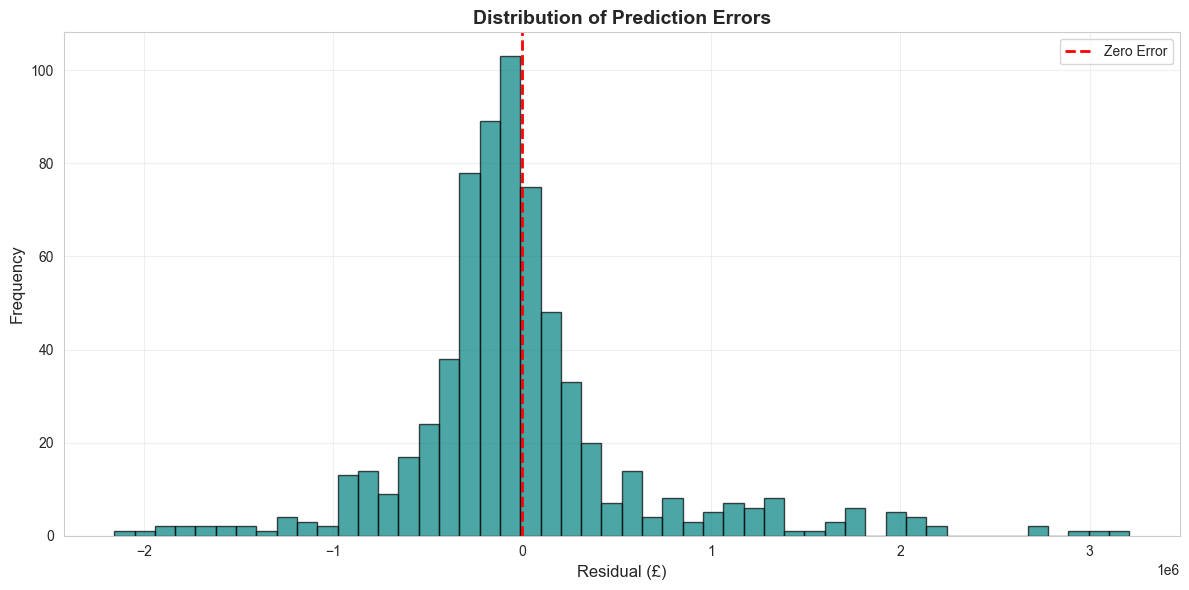


Residual Statistics:
  Mean Residual: £-8,698.59
  Median Residual: £-87,011.12
  Std Dev of Residuals: £647,176.86


In [25]:
# Distribution of residuals
plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Residual (£)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean Residual: £{residuals.mean():,.2f}")
print(f"  Median Residual: £{residuals.median():,.2f}")
print(f"  Std Dev of Residuals: £{residuals.std():,.2f}")

## 9. Sample Predictions

In [26]:
# Show some example predictions
sample_indices = np.random.choice(X_test.index, size=10, replace=False)
samples = X_test.loc[sample_indices]
actual_prices = y_test.loc[sample_indices]
predicted_prices = best_model.predict(scaler.transform(samples))

print("\n🏠 Sample Predictions:\n")
print("="*90)

for i, idx in enumerate(sample_indices):
    house_type_code = int(samples.loc[idx, 'House Type Encoded'])
    house_type = le_house_type.inverse_transform([house_type_code])[0]
    
    location_code = int(samples.loc[idx, 'Location Encoded'])
    location = le_location.inverse_transform([location_code])[0]
    
    area = samples.loc[idx, 'Area in sq ft']
    bedrooms = int(samples.loc[idx, 'No. of Bedrooms'])
    
    actual = actual_prices.loc[idx]
    predicted = predicted_prices[i]
    error = abs(actual - predicted)
    error_pct = (error / actual) * 100
    
    print(f"Property {i+1}:")
    print(f"  Type: {house_type} | Location: {location}")
    print(f"  Area: {area:.0f} sq ft | Bedrooms: {bedrooms}")
    print(f"  Actual Price: £{actual:,.2f}")
    print(f"  Predicted Price: £{predicted:,.2f}")
    print(f"  Error: £{error:,.2f} ({error_pct:.2f}%)")
    print("-" * 90)


🏠 Sample Predictions:

Property 1:
  Type: House | Location: Wimbledon
  Area: 3594 sq ft | Bedrooms: 5
  Actual Price: £2,350,000.00
  Predicted Price: £2,295,052.75
  Error: £54,947.25 (2.34%)
------------------------------------------------------------------------------------------
Property 2:
  Type: New development | Location:  Wandsworth
  Area: 460 sq ft | Bedrooms: 1
  Actual Price: £580,000.00
  Predicted Price: £452,184.19
  Error: £127,815.81 (22.04%)
------------------------------------------------------------------------------------------
Property 3:
  Type: House | Location: Walton-on-Thames
  Area: 5599 sq ft | Bedrooms: 6
  Actual Price: £3,450,000.00
  Predicted Price: £4,162,827.50
  Error: £712,827.50 (20.66%)
------------------------------------------------------------------------------------------
Property 4:
  Type: Flat / Apartment | Location: 20 Love Lane
  Area: 774 sq ft | Bedrooms: 2
  Actual Price: £400,000.00
  Predicted Price: £741,469.75
  Error: £341,46

## 10. Export the Model

In [27]:
# Create a model package with all necessary components
model_package = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': feature_columns,
    'model_name': best_model_name,
    'performance_metrics': {
        'r2_score': results[best_model_name]['test_r2'],
        'mae': results[best_model_name]['test_mae'],
        'rmse': results[best_model_name]['test_rmse']
    },
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save using joblib (recommended for sklearn models)
joblib.dump(model_package, 'london_house_price_model.pkl')
print("✅ Model saved as 'london_house_price_model.pkl'")

# Also save using pickle as backup
with open('london_house_price_model_backup.pkl', 'wb') as f:
    pickle.dump(model_package, f)
print("✅ Backup model saved as 'london_house_price_model_backup.pkl'")

# Save model info as JSON for reference
import json

model_info = {
    'model_name': best_model_name,
    'training_date': model_package['training_date'],
    'r2_score': float(results[best_model_name]['test_r2']),
    'mae': float(results[best_model_name]['test_mae']),
    'rmse': float(results[best_model_name]['test_rmse']),
    'features': feature_columns,
    'house_types': list(le_house_type.classes_),
    'num_locations': len(le_location.classes_),
    'training_samples': len(X_train),
    'test_samples': len(X_test)
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print("✅ Model info saved as 'model_info.json'")

✅ Model saved as 'london_house_price_model.pkl'
✅ Backup model saved as 'london_house_price_model_backup.pkl'
✅ Model info saved as 'model_info.json'


In [28]:
# Verify the saved model by loading and testing
loaded_model_package = joblib.load('london_house_price_model.pkl')

# Make a test prediction
test_sample = X_test.iloc[0:1]
test_sample_scaled = loaded_model_package['scaler'].transform(test_sample)
test_prediction = loaded_model_package['model'].predict(test_sample_scaled)

print("\n🔍 Model Verification:")
print(f"  Model loaded successfully: ✅")
print(f"  Test prediction: £{test_prediction[0]:,.2f}")
print(f"  Actual price: £{y_test.iloc[0]:,.2f}")
print(f"\n📦 Model Package Contents:")
print(f"  - Trained {loaded_model_package['model_name']} model")
print(f"  - Feature scaler")
print(f"  - Label encoders for categorical features")
print(f"  - Performance metrics")
print(f"  - Training metadata")


🔍 Model Verification:
  Model loaded successfully: ✅
  Test prediction: £751,460.88
  Actual price: £699,950.00

📦 Model Package Contents:
  - Trained XGBoost model
  - Feature scaler
  - Label encoders for categorical features
  - Performance metrics
  - Training metadata


## 11. Model Summary

In [29]:
# Final summary
print("="*80)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*80)
print(f"\n📊 Final Model: {best_model_name}")
print(f"\n🎯 Performance Metrics:")
print(f"  R² Score: {results[best_model_name]['test_r2']:.4f} ({results[best_model_name]['test_r2']*100:.2f}% accuracy)")
print(f"  Mean Absolute Error: £{results[best_model_name]['test_mae']:,.2f}")
print(f"  Root Mean Squared Error: £{results[best_model_name]['test_rmse']:,.2f}")
print(f"\n📁 Exported Files:")
print(f"  ✅ london_house_price_model.pkl (main model file)")
print(f"  ✅ london_house_price_model_backup.pkl (backup)")
print(f"  ✅ model_info.json (model metadata)")
print(f"\n🔧 Model Usage:")
print(f"  import joblib")
print(f"  model_pkg = joblib.load('london_house_price_model.pkl')")
print(f"  prediction = model_pkg['model'].predict(scaled_features)")
print("\n" + "="*80)

🎉 MODEL TRAINING COMPLETE!

📊 Final Model: XGBoost

🎯 Performance Metrics:
  R² Score: 0.7054 (70.54% accuracy)
  Mean Absolute Error: £412,124.87
  Root Mean Squared Error: £646,753.65

📁 Exported Files:
  ✅ london_house_price_model.pkl (main model file)
  ✅ london_house_price_model_backup.pkl (backup)
  ✅ model_info.json (model metadata)

🔧 Model Usage:
  import joblib
  model_pkg = joblib.load('london_house_price_model.pkl')
  prediction = model_pkg['model'].predict(scaled_features)

